In [1]:
import pandas as pd

chunk_size = 500_000
filtered_chunks = []

total_rows = 0
total_december_rows = 0

for chunk in pd.read_csv(
    "../data/flights.csv",
    chunksize=chunk_size,
    low_memory=False
):
    dec_chunk = chunk[chunk["MONTH"] == 12]

    filtered_chunks.append(dec_chunk)

    total_rows += len(chunk)
    total_december_rows += len(dec_chunk)

    print(
        f"Processed: {total_rows:,} rows | "
        f"December rows: {total_december_rows:,}"
    )

flights_dec = pd.concat(
    filtered_chunks,
    ignore_index=True
)

print("\nFinal shape:", flights_dec.shape)

Processed: 500,000 rows | December rows: 0
Processed: 1,000,000 rows | December rows: 0
Processed: 1,500,000 rows | December rows: 0
Processed: 2,000,000 rows | December rows: 0
Processed: 2,500,000 rows | December rows: 0
Processed: 3,000,000 rows | December rows: 0
Processed: 3,500,000 rows | December rows: 0
Processed: 4,000,000 rows | December rows: 0
Processed: 4,500,000 rows | December rows: 0
Processed: 5,000,000 rows | December rows: 0
Processed: 5,500,000 rows | December rows: 160,151
Processed: 5,819,079 rows | December rows: 479,230

Final shape: (479230, 31)


In [2]:
flights_dec.to_csv(
    "../data/flights_dec2015.csv",
    index=False
)

print("December dataset saved successfully!")

December dataset saved successfully!


In [3]:
import os
size_mb = os.path.getsize("../data/flights_dec2015.csv") / (1024*1024)
print(f"{size_mb:.1f} MB")

57.4 MB


In [4]:
check = pd.read_csv("../data/flights_dec2015.csv")

print("Shape:", check.shape)
print("Months:", check["MONTH"].unique())

Shape: (479230, 31)
Months: [12]


In [5]:
check.isnull().sum().sort_values(ascending=False).head(15)

CANCELLATION_REASON    471167
LATE_AIRCRAFT_DELAY    382458
WEATHER_DELAY          382458
AIRLINE_DELAY          382458
AIR_SYSTEM_DELAY       382458
SECURITY_DELAY         382458
ELAPSED_TIME             9513
AIR_TIME                 9513
ARRIVAL_DELAY            9513
WHEELS_ON                8453
TAXI_IN                  8453
ARRIVAL_TIME             8453
WHEELS_OFF               7961
TAXI_OUT                 7961
DEPARTURE_TIME           7679
dtype: int64

In [6]:
print(check["CANCELLED"].value_counts())

CANCELLED
0    471167
1      8063
Name: count, dtype: int64


In [7]:
print(
    "Cancelled flights:",
    check["CANCELLED"].sum()
)

print(
    "Cancelled rate:",
    check["CANCELLED"].mean()
)

Cancelled flights: 8063
Cancelled rate: 0.016824906621037916


In [8]:
print(
    pd.crosstab(
        check["CANCELLED"],
        check["ARRIVAL_DELAY"].isna()
    )
)

ARRIVAL_DELAY   False  True 
CANCELLED                   
0              469717   1450
1                   0   8063


In [9]:
print(check["CANCELLED"].value_counts())

print(
    "Cancelled flights:",
    check["CANCELLED"].sum()
)

print(
    "Cancelled rate:",
    check["CANCELLED"].mean()
)

CANCELLED
0    471167
1      8063
Name: count, dtype: int64
Cancelled flights: 8063
Cancelled rate: 0.016824906621037916


In [10]:
print(
    pd.crosstab(
        check["CANCELLED"],
        check["ARRIVAL_DELAY"].isna()
    )
)

ARRIVAL_DELAY   False  True 
CANCELLED                   
0              469717   1450
1                   0   8063


In [11]:
pd.crosstab(
    check["CANCELLED"],
    check["DIVERTED"]
)

DIVERTED,0,1
CANCELLED,,
0,469717,1450
1,8063,0


In [12]:
print(
    "Non-cancelled + missing arrival delay:",
    ((check["CANCELLED"] == 0) & check["ARRIVAL_DELAY"].isna()).sum()
)

print(
    "Of those, diverted:",
    (
        (check["CANCELLED"] == 0)
        & check["ARRIVAL_DELAY"].isna()
        & (check["DIVERTED"] == 1)
    ).sum()
)

Non-cancelled + missing arrival delay: 1450
Of those, diverted: 1450


In [13]:
delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

print(
    check[delay_cols].notna().sum()
)

AIR_SYSTEM_DELAY       96772
SECURITY_DELAY         96772
AIRLINE_DELAY          96772
LATE_AIRCRAFT_DELAY    96772
WEATHER_DELAY          96772
dtype: int64


In [14]:
print(
    check[delay_cols].notna().all(axis=1).value_counts()
)

False    382458
True      96772
Name: count, dtype: int64


In [15]:
check.loc[
    check[delay_cols].notna().any(axis=1),
    "ARRIVAL_DELAY"
].describe()

count    96772.000000
mean        62.616418
std         71.413763
min         15.000000
25%         23.000000
50%         38.000000
75%         73.000000
max       1636.000000
Name: ARRIVAL_DELAY, dtype: float64

In [16]:
print(
    "Rows with delay-cause data:",
    check[delay_cols].notna().any(axis=1).sum()
)

print(
    "Rows with positive arrival delay:",
    (check["ARRIVAL_DELAY"] > 0).sum()
)

Rows with delay-cause data: 96772
Rows with positive arrival delay: 179494


In [18]:
print(
    pd.crosstab(
        check["ARRIVAL_DELAY"] > 15,
        check[delay_cols].notna().all(axis=1)
    )
)

col_0           False  True 
ARRIVAL_DELAY               
False          382458   3459
True                0  93313


In [19]:
print(
    "Delayed >15:",
    (check["ARRIVAL_DELAY"] > 15).sum()
)

print(
    "Cause data present:",
    check[delay_cols].notna().all(axis=1).sum()
)

Delayed >15: 93313
Cause data present: 96772


In [20]:
flights_dec = check.copy()

# Remove rows where scheduled departure/arrival is unavailable
flights_dec = flights_dec.dropna(
    subset=[
        "SCHEDULED_DEPARTURE",
        "SCHEDULED_ARRIVAL"
    ]
)

# Delay-cause columns
delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

# For our cause analysis, treat missing cause values as 0
flights_dec[delay_cols] = flights_dec[delay_cols].fillna(0)

# Main definition of a delayed operated flight
flights_dec["IS_DELAYED"] = (
    (flights_dec["ARRIVAL_DELAY"] > 15)
    & (flights_dec["CANCELLED"] == 0)
    & (flights_dec["DIVERTED"] == 0)
).astype(int)

print("Cleaned shape:", flights_dec.shape)
print("Delayed flights:", flights_dec["IS_DELAYED"].sum())

Cleaned shape: (479230, 32)
Delayed flights: 93313


In [21]:
operated = flights_dec[
    (flights_dec["CANCELLED"] == 0) &
    (flights_dec["DIVERTED"] == 0)
]

delay_rate = operated["IS_DELAYED"].mean()

print("Operated flights:", len(operated))
print("Delayed flights:", operated["IS_DELAYED"].sum())
print("Delay rate:", delay_rate)
print("Delay rate (%):", delay_rate * 100)

Operated flights: 469717
Delayed flights: 93313
Delay rate: 0.19865791529793472
Delay rate (%): 19.865791529793473


In [22]:
airlines = pd.read_csv("../data/airlines.csv")

print(airlines)

   IATA_CODE                       AIRLINE
0         UA         United Air Lines Inc.
1         AA        American Airlines Inc.
2         US               US Airways Inc.
3         F9        Frontier Airlines Inc.
4         B6               JetBlue Airways
5         OO         Skywest Airlines Inc.
6         AS          Alaska Airlines Inc.
7         NK              Spirit Air Lines
8         WN        Southwest Airlines Co.
9         DL          Delta Air Lines Inc.
10        EV   Atlantic Southeast Airlines
11        HA        Hawaiian Airlines Inc.
12        MQ  American Eagle Airlines Inc.
13        VX                Virgin America


In [23]:
# Rename airline name column before merging
airlines = airlines.rename(columns={
    "AIRLINE": "AIRLINE_NAME"
})

# Merge airline names into our flight dataset
flights_dec = flights_dec.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left"
)

print("Shape after merge:", flights_dec.shape)
print("\nNew columns:")
print(flights_dec[["AIRLINE", "AIRLINE_NAME"]].head())

Shape after merge: (479230, 34)

New columns:
  AIRLINE            AIRLINE_NAME
0      AA  American Airlines Inc.
1      DL    Delta Air Lines Inc.
2      AA  American Airlines Inc.
3      UA   United Air Lines Inc.
4      AA  American Airlines Inc.


In [24]:
print("Missing airline names:", flights_dec["AIRLINE_NAME"].isna().sum())
print("Unique airlines:", flights_dec["AIRLINE_NAME"].nunique())

Missing airline names: 0
Unique airlines: 13


In [25]:
print("Airlines present in December 2015:")
print(
    flights_dec[["AIRLINE", "AIRLINE_NAME"]]
    .drop_duplicates()
    .sort_values("AIRLINE")
    .to_string(index=False)
)

print("\nAirlines in lookup table but absent from December data:")
print(
    sorted(
        set(airlines["IATA_CODE"]) -
        set(flights_dec["AIRLINE"].unique())
    )
)

Airlines present in December 2015:
AIRLINE                 AIRLINE_NAME
     AA       American Airlines Inc.
     AS         Alaska Airlines Inc.
     B6              JetBlue Airways
     DL         Delta Air Lines Inc.
     EV  Atlantic Southeast Airlines
     F9       Frontier Airlines Inc.
     HA       Hawaiian Airlines Inc.
     MQ American Eagle Airlines Inc.
     NK             Spirit Air Lines
     OO        Skywest Airlines Inc.
     UA        United Air Lines Inc.
     VX               Virgin America
     WN       Southwest Airlines Co.

Airlines in lookup table but absent from December data:
['US']


In [30]:
flights_dec.to_csv(
    "../data/flights_dec2015_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")
print("Final shape:", flights_dec.shape)

Clean dataset saved successfully.
Final shape: (479230, 34)


In [32]:
operated = flights_dec[
    (flights_dec["CANCELLED"] == 0) &
    (flights_dec["DIVERTED"] == 0)
]

print("Operated shape:", operated.shape)
print("AIRLINE_NAME exists:", "AIRLINE_NAME" in operated.columns)

Operated shape: (469717, 34)
AIRLINE_NAME exists: True


In [33]:
airline_summary = (
    operated
    .groupby("AIRLINE_NAME")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
    .reset_index()
)

airline_summary["delay_rate"] = (
    airline_summary["delayed_flights"]
    / airline_summary["total_flights"]
    * 100
)

airline_summary = airline_summary.sort_values(
    "delay_rate",
    ascending=False
)

airline_summary

,AIRLINE_NAME,total_flights,delayed_flights,avg_arrival_delay,delay_rate
10,Spirit Air Lines,10473,3042,12.733123,29.046119
7,JetBlue Airways,23197,6651,13.839290,28.671811
12,Virgin America,5470,1487,13.498720,27.184644
8,Skywest Airlines Inc.,45984,10836,10.947612,23.564718
5,Frontier Airlines Inc.,8018,1878,9.346221,23.422300
9,Southwest Airlines Co.,105569,22840,6.720893,21.635139
11,United Air Lines Inc.,42554,8481,7.012079,19.929971
3,Atlantic Southeast Airlines,42430,8013,6.685176,18.885223
1,American Airlines Inc.,75078,13840,4.149684,18.434162
2,American Eagle Airlines Inc.,20091,3113,0.662486,15.494500


In [2]:
import pandas as pd

flights_dec = pd.read_csv("../data/flights_dec2015_clean.csv")

print("Shape:", flights_dec.shape)

Shape: (479230, 34)


In [3]:
operated = flights_dec[
    (flights_dec["CANCELLED"] == 0) &
    (flights_dec["DIVERTED"] == 0)
]

print("Operated flights:", len(operated))
print("Delayed flights:", operated["IS_DELAYED"].sum())

Operated flights: 469717
Delayed flights: 93313


In [4]:
airline_summary = (
    operated
    .groupby("AIRLINE_NAME")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
    .reset_index()
)

airline_summary["delay_rate"] = (
    airline_summary["delayed_flights"]
    / airline_summary["total_flights"]
    * 100
)

airline_summary = airline_summary.sort_values(
    "delay_rate",
    ascending=False
)

airline_summary

,AIRLINE_NAME,total_flights,delayed_flights,avg_arrival_delay,delay_rate
10,Spirit Air Lines,10473,3042,12.733123,29.046119
7,JetBlue Airways,23197,6651,13.839290,28.671811
12,Virgin America,5470,1487,13.498720,27.184644
8,Skywest Airlines Inc.,45984,10836,10.947612,23.564718
5,Frontier Airlines Inc.,8018,1878,9.346221,23.422300
9,Southwest Airlines Co.,105569,22840,6.720893,21.635139
11,United Air Lines Inc.,42554,8481,7.012079,19.929971
3,Atlantic Southeast Airlines,42430,8013,6.685176,18.885223
1,American Airlines Inc.,75078,13840,4.149684,18.434162
2,American Eagle Airlines Inc.,20091,3113,0.662486,15.494500


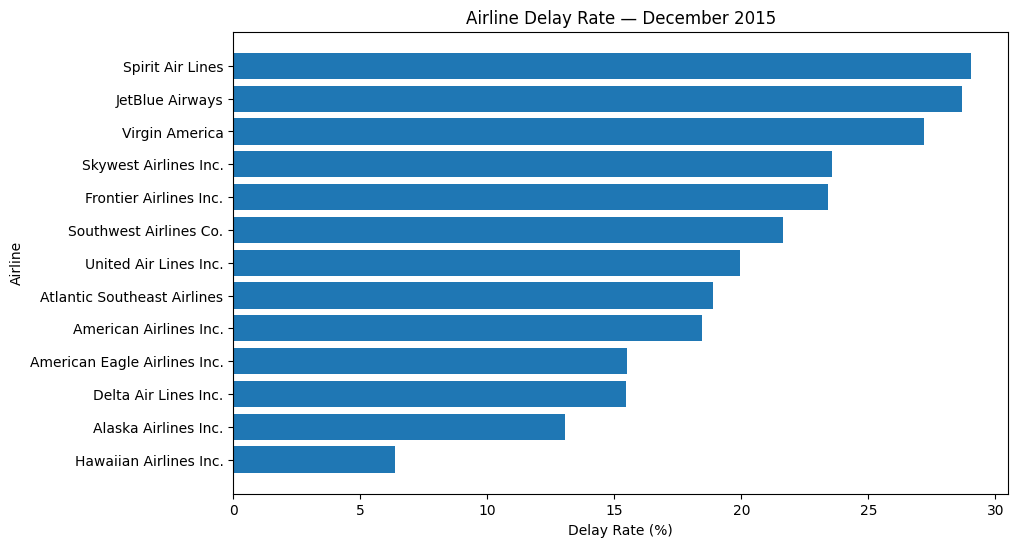

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    airline_summary["AIRLINE_NAME"],
    airline_summary["delay_rate"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")
plt.title("Airline Delay Rate — December 2015")

plt.gca().invert_yaxis()

plt.show()

In [6]:
airline_summary[
    ["AIRLINE_NAME", "total_flights", "delayed_flights", "delay_rate"]
].sort_values(
    "total_flights",
    ascending=False
)

,AIRLINE_NAME,total_flights,delayed_flights,delay_rate
9,Southwest Airlines Co.,105569,22840,21.635139
1,American Airlines Inc.,75078,13840,18.434162
4,Delta Air Lines Inc.,70288,10866,15.459253
8,Skywest Airlines Inc.,45984,10836,23.564718
11,United Air Lines Inc.,42554,8481,19.929971
3,Atlantic Southeast Airlines,42430,8013,18.885223
7,JetBlue Airways,23197,6651,28.671811
2,American Eagle Airlines Inc.,20091,3113,15.494500
0,Alaska Airlines Inc.,14310,1868,13.053809
10,Spirit Air Lines,10473,3042,29.046119


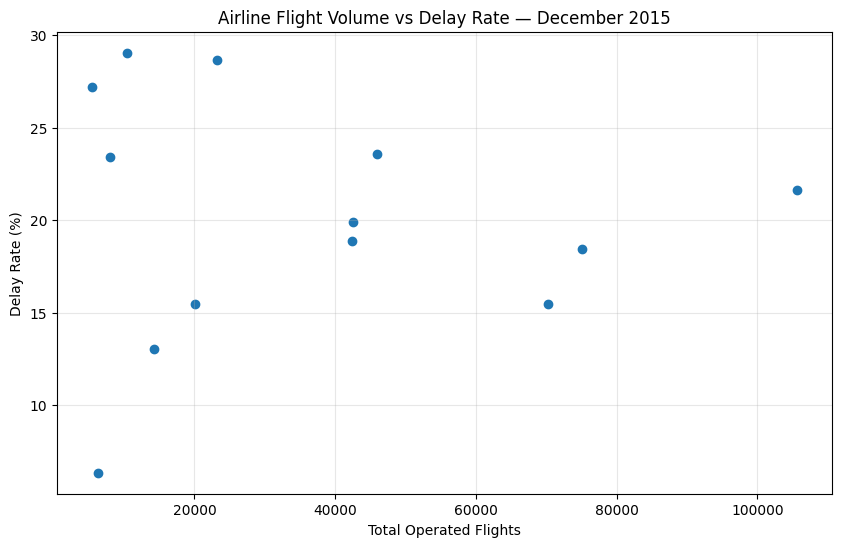

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(
    airline_summary["total_flights"],
    airline_summary["delay_rate"]
)

plt.xlabel("Total Operated Flights")
plt.ylabel("Delay Rate (%)")
plt.title("Airline Flight Volume vs Delay Rate — December 2015")

plt.grid(True, alpha=0.3)

plt.show()

In [8]:
correlation = airline_summary["total_flights"].corr(
    airline_summary["delay_rate"]
)

print("Correlation between flight volume and delay rate:", correlation)

Correlation between flight volume and delay rate: -0.04225292596164937


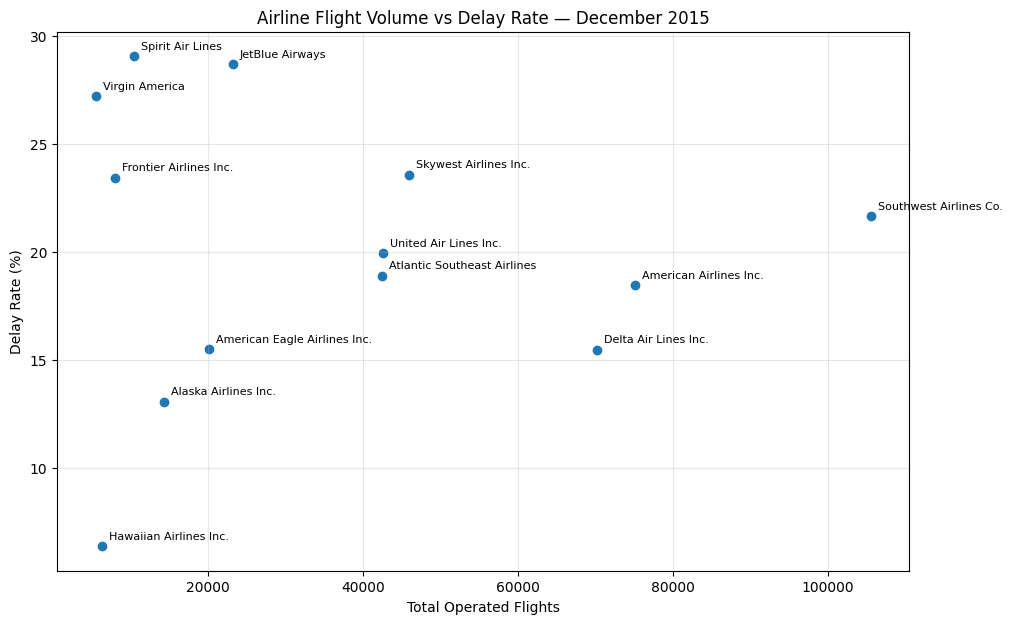

In [9]:
plt.figure(figsize=(11, 7))

plt.scatter(
    airline_summary["total_flights"],
    airline_summary["delay_rate"]
)

for _, row in airline_summary.iterrows():
    plt.annotate(
        row["AIRLINE_NAME"],
        (row["total_flights"], row["delay_rate"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Total Operated Flights")
plt.ylabel("Delay Rate (%)")
plt.title("Airline Flight Volume vs Delay Rate — December 2015")

plt.grid(True, alpha=0.3)
plt.show()

In [10]:
delayed_airlines = (
    operated[operated["IS_DELAYED"] == 1]
    .groupby("AIRLINE_NAME")
    .agg(
        delayed_flights=("IS_DELAYED", "count"),
        avg_delay_when_delayed=("ARRIVAL_DELAY", "mean"),
        median_delay_when_delayed=("ARRIVAL_DELAY", "median")
    )
    .reset_index()
    .sort_values(
        "avg_delay_when_delayed",
        ascending=False
    )
)

delayed_airlines

,AIRLINE_NAME,delayed_flights,avg_delay_when_delayed,median_delay_when_delayed
11,United Air Lines Inc.,8481,80.989742,51.0
5,Frontier Airlines Inc.,1878,76.670927,48.0
4,Delta Air Lines Inc.,10866,71.102982,40.0
12,Virgin America,1487,70.199059,49.0
3,Atlantic Southeast Airlines,8013,69.723449,44.0
8,Skywest Airlines Inc.,10836,68.067553,42.0
7,JetBlue Airways,6651,66.334085,44.0
2,American Eagle Airlines Inc.,3113,65.918085,42.0
1,American Airlines Inc.,13840,60.531503,36.0
10,Spirit Air Lines,3042,58.407298,39.0


In [11]:
delay_cause_totals = (
    operated[operated["IS_DELAYED"] == 1][
        [
            "AIR_SYSTEM_DELAY",
            "SECURITY_DELAY",
            "AIRLINE_DELAY",
            "LATE_AIRCRAFT_DELAY",
            "WEATHER_DELAY"
        ]
    ]
    .sum()
    .sort_values(ascending=False)
)

delay_cause_totals

LATE_AIRCRAFT_DELAY    2525932.0
AIRLINE_DELAY          1881224.0
AIR_SYSTEM_DELAY       1264646.0
WEATHER_DELAY           326068.0
SECURITY_DELAY            9761.0
dtype: float64

In [12]:
cause_flight_counts = (
    operated[operated["IS_DELAYED"] == 1][
        [
            "AIR_SYSTEM_DELAY",
            "SECURITY_DELAY",
            "AIRLINE_DELAY",
            "LATE_AIRCRAFT_DELAY",
            "WEATHER_DELAY"
        ]
    ]
    .gt(0)
    .sum()
    .sort_values(ascending=False)
)

cause_flight_counts

AIRLINE_DELAY          52496
LATE_AIRCRAFT_DELAY    51759
AIR_SYSTEM_DELAY       48379
WEATHER_DELAY           5831
SECURITY_DELAY           500
dtype: int64

In [13]:
cause_analysis = pd.DataFrame({
    "flights_affected": cause_flight_counts,
    "total_delay_minutes": delay_cause_totals
})

cause_analysis["avg_minutes_per_affected_flight"] = (
    cause_analysis["total_delay_minutes"]
    / cause_analysis["flights_affected"]
)

cause_analysis.sort_values(
    "avg_minutes_per_affected_flight",
    ascending=False
)

,flights_affected,total_delay_minutes,avg_minutes_per_affected_flight
WEATHER_DELAY,5831,326068.0,55.919739
LATE_AIRCRAFT_DELAY,51759,2525932.0,48.801793
AIRLINE_DELAY,52496,1881224.0,35.835568
AIR_SYSTEM_DELAY,48379,1264646.0,26.140391
SECURITY_DELAY,500,9761.0,19.522000


In [14]:
cause_analysis["minute_share"] = (
    cause_analysis["total_delay_minutes"]
    / cause_analysis["total_delay_minutes"].sum()
    * 100
)

cause_analysis.sort_values(
    "minute_share",
    ascending=False
)

,flights_affected,total_delay_minutes,avg_minutes_per_affected_flight,minute_share
LATE_AIRCRAFT_DELAY,51759,2525932.0,48.801793,42.045392
AIRLINE_DELAY,52496,1881224.0,35.835568,31.313907
AIR_SYSTEM_DELAY,48379,1264646.0,26.140391,21.050660
WEATHER_DELAY,5831,326068.0,55.919739,5.427564
SECURITY_DELAY,500,9761.0,19.522000,0.162477


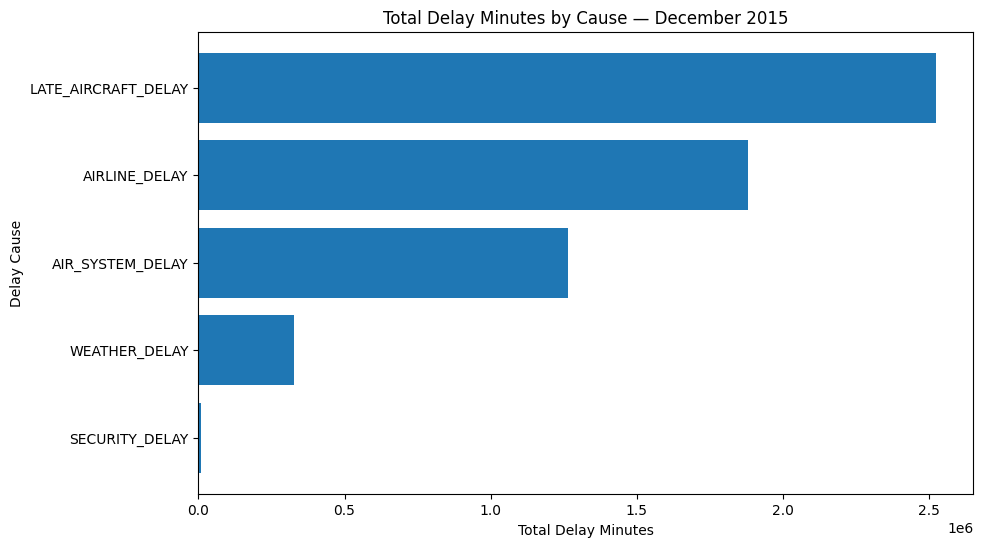

In [15]:
plt.figure(figsize=(10, 6))

cause_plot = cause_analysis.sort_values(
    "total_delay_minutes",
    ascending=True
)

plt.barh(
    cause_plot.index,
    cause_plot["total_delay_minutes"]
)

plt.xlabel("Total Delay Minutes")
plt.ylabel("Delay Cause")
plt.title("Total Delay Minutes by Cause — December 2015")

plt.show()

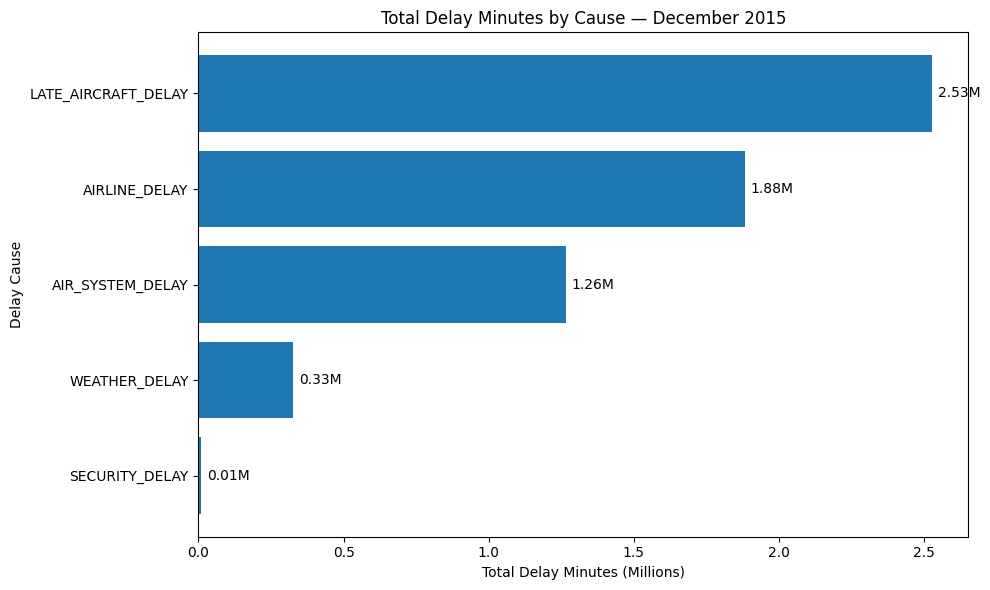

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

cause_plot = cause_analysis.sort_values(
    "total_delay_minutes",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    cause_plot.index,
    cause_plot["total_delay_minutes"]
)

plt.xlabel("Total Delay Minutes (Millions)")
plt.ylabel("Delay Cause")
plt.title("Total Delay Minutes by Cause — December 2015")

# Format x-axis in millions
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")
)

# Add values to bars
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.02e6,
        bar.get_y() + bar.get_height()/2,
        f"{value/1e6:.2f}M",
        va="center"
    )

plt.tight_layout()
plt.show()

In [17]:
flights_dec["DEP_HOUR"] = (
    flights_dec["SCHEDULED_DEPARTURE"] // 100
).astype(int)

flights_dec[["SCHEDULED_DEPARTURE", "DEP_HOUR"]].head(10)

,SCHEDULED_DEPARTURE,DEP_HOUR
0,5,0
1,5,0
2,10,0
3,14,0
4,15,0
5,15,0
6,20,0
7,25,0
8,25,0
9,25,0


In [19]:
# Create departure hour from scheduled departure time
flights_dec["DEP_HOUR"] = (
    flights_dec["SCHEDULED_DEPARTURE"] // 100
).astype(int)

# Recreate operated flights AFTER creating DEP_HOUR
operated = flights_dec[
    (flights_dec["CANCELLED"] == 0) &
    (flights_dec["DIVERTED"] == 0)
].copy()

# Check that the column exists
print("DEP_HOUR in flights_dec:", "DEP_HOUR" in flights_dec.columns)
print("DEP_HOUR in operated:", "DEP_HOUR" in operated.columns)
print("Operated shape:", operated.shape)

DEP_HOUR in flights_dec: True
DEP_HOUR in operated: True
Operated shape: (469717, 35)


In [20]:
hour_counts = (
    operated
    .groupby("DEP_HOUR")
    .size()
    .reset_index(name="total_flights")
)

hour_counts

,DEP_HOUR,total_flights
0,0,1533
1,1,547
2,2,164
3,3,86
4,4,66
5,5,11135
6,6,32632
7,7,31186
8,8,30089
9,9,28643


In [21]:
hourly_delay = (
    operated
    .groupby("DEP_HOUR")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum")
    )
    .reset_index()
)

hourly_delay["delay_rate"] = (
    hourly_delay["delayed_flights"]
    / hourly_delay["total_flights"]
    * 100
)

hourly_delay

,DEP_HOUR,total_flights,delayed_flights,delay_rate
0,0,1533,299,19.504240
1,1,547,112,20.475320
2,2,164,29,17.682927
3,3,86,21,24.418605
4,4,66,22,33.333333
5,5,11135,1092,9.806915
6,6,32632,3620,11.093405
7,7,31186,4123,13.220676
8,8,30089,4437,14.746253
9,9,28643,4736,16.534581


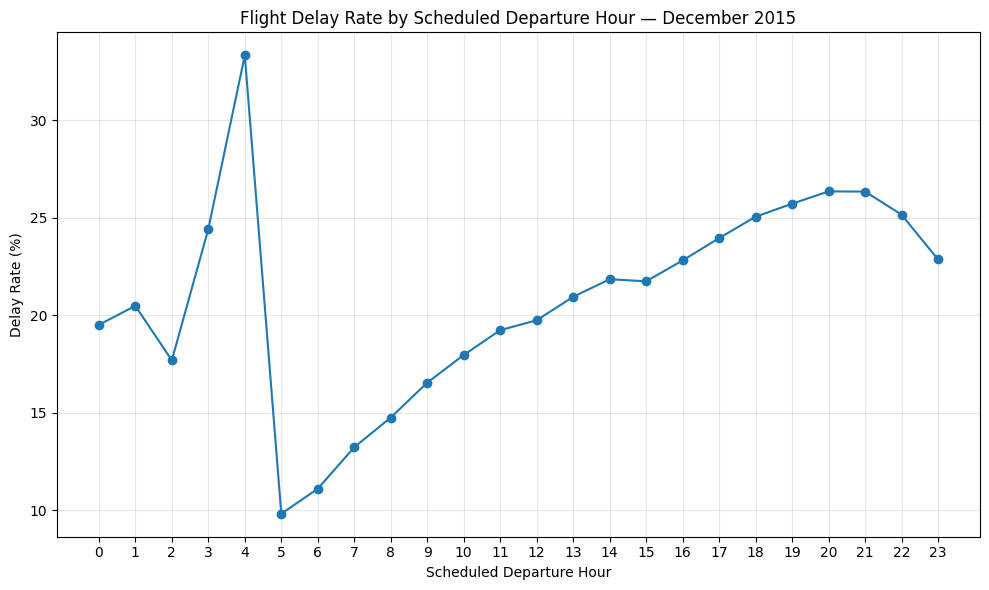

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_delay["DEP_HOUR"],
    hourly_delay["delay_rate"],
    marker="o"
)

plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Scheduled Departure Hour — December 2015")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
operated[["TAIL_NUMBER", "SCHEDULED_DEPARTURE", "ARRIVAL_DELAY"]].head(10)

,TAIL_NUMBER,SCHEDULED_DEPARTURE,ARRIVAL_DELAY
0,N3KSAA,5,-17.0
1,N820DN,5,-4.0
2,N850AA,10,-8.0
3,N38473,14,-30.0
4,N199UW,15,5.0
5,N977UY,15,-32.0
6,N227FR,20,-28.0
7,N625NK,25,-7.0
8,N556UW,25,-12.0
9,N556NW,25,-32.0


In [24]:
aircraft_counts = (
    operated
    .groupby("TAIL_NUMBER")
    .size()
    .reset_index(name="flight_count")
    .sort_values("flight_count", ascending=False)
)

aircraft_counts.head(10)

,TAIL_NUMBER,flight_count
1773,N493HA,383
1768,N492HA,373
1764,N491HA,363
1760,N490HA,335
1731,N483HA,325
1748,N487HA,320
1723,N481HA,318
1694,N475HA,312
1735,N484HA,311
1717,N480HA,296


In [25]:
operated["SCHEDULED_DATETIME"] = pd.to_datetime(
    "2015-12-" +
    operated["DAY"].astype(str).str.zfill(2) +
    " " +
    operated["SCHEDULED_DEPARTURE"].astype(int).astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M"
)

operated[
    ["DAY", "SCHEDULED_DEPARTURE", "SCHEDULED_DATETIME"]
].head(10)

,DAY,SCHEDULED_DEPARTURE,SCHEDULED_DATETIME
0,1,5,2015-12-01 00:05:00
1,1,5,2015-12-01 00:05:00
2,1,10,2015-12-01 00:10:00
3,1,14,2015-12-01 00:14:00
4,1,15,2015-12-01 00:15:00
5,1,15,2015-12-01 00:15:00
6,1,20,2015-12-01 00:20:00
7,1,25,2015-12-01 00:25:00
8,1,25,2015-12-01 00:25:00
9,1,25,2015-12-01 00:25:00


In [26]:
operated = operated.sort_values(
    ["TAIL_NUMBER", "SCHEDULED_DATETIME"]
).copy()

operated[
    ["TAIL_NUMBER", "DAY", "SCHEDULED_DEPARTURE", "SCHEDULED_DATETIME", "ARRIVAL_DELAY"]
].head(20)

,TAIL_NUMBER,DAY,SCHEDULED_DEPARTURE,SCHEDULED_DATETIME,ARRIVAL_DELAY
3458,7820L,1,845,2015-12-01 08:45:00,5.0
6233,7820L,1,1135,2015-12-01 11:35:00,2.0
6942,7820L,1,1220,2015-12-01 12:20:00,0.0
8539,7820L,1,1400,2015-12-01 14:00:00,-11.0
13654,7820L,1,1920,2015-12-01 19:20:00,-5.0
15007,7820L,1,2110,2015-12-01 21:10:00,-12.0
17079,7820L,2,635,2015-12-02 06:35:00,-20.0
21112,7820L,2,1040,2015-12-02 10:40:00,22.0
27051,7820L,2,1655,2015-12-02 16:55:00,1.0
30420,7820L,2,2025,2015-12-02 20:25:00,1.0


In [27]:
operated["PREV_ARRIVAL_DELAY"] = (
    operated
    .groupby("TAIL_NUMBER")["ARRIVAL_DELAY"]
    .shift(1)
)

operated[
    [
        "TAIL_NUMBER",
        "SCHEDULED_DATETIME",
        "ARRIVAL_DELAY",
        "PREV_ARRIVAL_DELAY"
    ]
].head(20)

,TAIL_NUMBER,SCHEDULED_DATETIME,ARRIVAL_DELAY,PREV_ARRIVAL_DELAY
3458,7820L,2015-12-01 08:45:00,5.0,NaN
6233,7820L,2015-12-01 11:35:00,2.0,5.0
6942,7820L,2015-12-01 12:20:00,0.0,2.0
8539,7820L,2015-12-01 14:00:00,-11.0,0.0
13654,7820L,2015-12-01 19:20:00,-5.0,-11.0
15007,7820L,2015-12-01 21:10:00,-12.0,-5.0
17079,7820L,2015-12-02 06:35:00,-20.0,-12.0
21112,7820L,2015-12-02 10:40:00,22.0,-20.0
27051,7820L,2015-12-02 16:55:00,1.0,22.0
30420,7820L,2015-12-02 20:25:00,1.0,1.0


In [28]:
operated["PREV_WAS_DELAYED"] = (
    operated["PREV_ARRIVAL_DELAY"] > 15
).astype(int)

operated["CURRENT_IS_DELAYED"] = (
    operated["ARRIVAL_DELAY"] > 15
).astype(int)

operated["POTENTIAL_CASCADE"] = (
    (operated["PREV_WAS_DELAYED"] == 1) &
    (operated["CURRENT_IS_DELAYED"] == 1)
).astype(int)

operated[
    [
        "TAIL_NUMBER",
        "SCHEDULED_DATETIME",
        "PREV_ARRIVAL_DELAY",
        "ARRIVAL_DELAY",
        "POTENTIAL_CASCADE"
    ]
].head(20)

,TAIL_NUMBER,SCHEDULED_DATETIME,PREV_ARRIVAL_DELAY,ARRIVAL_DELAY,POTENTIAL_CASCADE
3458,7820L,2015-12-01 08:45:00,NaN,5.0,0
6233,7820L,2015-12-01 11:35:00,5.0,2.0,0
6942,7820L,2015-12-01 12:20:00,2.0,0.0,0
8539,7820L,2015-12-01 14:00:00,0.0,-11.0,0
13654,7820L,2015-12-01 19:20:00,-11.0,-5.0,0
15007,7820L,2015-12-01 21:10:00,-5.0,-12.0,0
17079,7820L,2015-12-02 06:35:00,-12.0,-20.0,0
21112,7820L,2015-12-02 10:40:00,-20.0,22.0,0
27051,7820L,2015-12-02 16:55:00,22.0,1.0,0
30420,7820L,2015-12-02 20:25:00,1.0,1.0,0


In [29]:
operated["PREV_FLIGHT_TIME_GAP_HOURS"] = (
    operated["SCHEDULED_DATETIME"]
    - operated.groupby("TAIL_NUMBER")["SCHEDULED_DATETIME"].shift(1)
).dt.total_seconds() / 3600

operated[
    [
        "TAIL_NUMBER",
        "SCHEDULED_DATETIME",
        "PREV_FLIGHT_TIME_GAP_HOURS",
        "PREV_ARRIVAL_DELAY",
        "ARRIVAL_DELAY"
    ]
].head(20)

,TAIL_NUMBER,SCHEDULED_DATETIME,PREV_FLIGHT_TIME_GAP_HOURS,PREV_ARRIVAL_DELAY,ARRIVAL_DELAY
3458,7820L,2015-12-01 08:45:00,NaN,NaN,5.0
6233,7820L,2015-12-01 11:35:00,2.833333,5.0,2.0
6942,7820L,2015-12-01 12:20:00,0.750000,2.0,0.0
8539,7820L,2015-12-01 14:00:00,1.666667,0.0,-11.0
13654,7820L,2015-12-01 19:20:00,5.333333,-11.0,-5.0
15007,7820L,2015-12-01 21:10:00,1.833333,-5.0,-12.0
17079,7820L,2015-12-02 06:35:00,9.416667,-12.0,-20.0
21112,7820L,2015-12-02 10:40:00,4.083333,-20.0,22.0
27051,7820L,2015-12-02 16:55:00,6.250000,22.0,1.0
30420,7820L,2015-12-02 20:25:00,3.500000,1.0,1.0


In [30]:
operated["POTENTIAL_CASCADE"] = (
    (operated["PREV_ARRIVAL_DELAY"] > 15) &
    (operated["ARRIVAL_DELAY"] > 15) &
    (operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4)
).astype(int)

operated[
    [
        "TAIL_NUMBER",
        "SCHEDULED_DATETIME",
        "PREV_FLIGHT_TIME_GAP_HOURS",
        "PREV_ARRIVAL_DELAY",
        "ARRIVAL_DELAY",
        "POTENTIAL_CASCADE"
    ]
].head(20)

,TAIL_NUMBER,SCHEDULED_DATETIME,PREV_FLIGHT_TIME_GAP_HOURS,PREV_ARRIVAL_DELAY,ARRIVAL_DELAY,POTENTIAL_CASCADE
3458,7820L,2015-12-01 08:45:00,NaN,NaN,5.0,0
6233,7820L,2015-12-01 11:35:00,2.833333,5.0,2.0,0
6942,7820L,2015-12-01 12:20:00,0.750000,2.0,0.0,0
8539,7820L,2015-12-01 14:00:00,1.666667,0.0,-11.0,0
13654,7820L,2015-12-01 19:20:00,5.333333,-11.0,-5.0,0
15007,7820L,2015-12-01 21:10:00,1.833333,-5.0,-12.0,0
17079,7820L,2015-12-02 06:35:00,9.416667,-12.0,-20.0,0
21112,7820L,2015-12-02 10:40:00,4.083333,-20.0,22.0,0
27051,7820L,2015-12-02 16:55:00,6.250000,22.0,1.0,0
30420,7820L,2015-12-02 20:25:00,3.500000,1.0,1.0,0


In [31]:
cascade_count = operated["POTENTIAL_CASCADE"].sum()

print("Potential cascading delays:", cascade_count)

Potential cascading delays: 33808


In [32]:
delayed_flights = operated["IS_DELAYED"].sum()

cascade_rate = (
    cascade_count / delayed_flights * 100
)

print("Delayed flights:", delayed_flights)
print("Potential cascade rate:", cascade_rate)

Delayed flights: 93313
Potential cascade rate: 36.23075027059466


In [33]:
cascade_comparison = (
    operated[
        operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4
    ]
    .groupby("PREV_WAS_DELAYED")
    .agg(
        total_flights=("ARRIVAL_DELAY", "count"),
        delayed_flights=("IS_DELAYED", "sum")
    )
    .reset_index()
)

cascade_comparison["delay_rate"] = (
    cascade_comparison["delayed_flights"]
    / cascade_comparison["total_flights"]
    * 100
)

cascade_comparison

,PREV_WAS_DELAYED,total_flights,delayed_flights,delay_rate
0,0,224390,24676,10.996925
1,1,47866,33808,70.630510


In [34]:
operated["PREV_DELAY_BUCKET"] = pd.cut(
    operated["PREV_ARRIVAL_DELAY"],
    bins=[15, 30, 60, 120, float("inf")],
    labels=["16–30 min", "31–60 min", "61–120 min", "120+ min"]
)

previous_delay_analysis = (
    operated[
        operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4
    ]
    .groupby("PREV_DELAY_BUCKET", observed=True)
    .agg(
        total_flights=("ARRIVAL_DELAY", "count"),
        delayed_flights=("IS_DELAYED", "sum")
    )
    .reset_index()
)

previous_delay_analysis["delay_rate"] = (
    previous_delay_analysis["delayed_flights"]
    / previous_delay_analysis["total_flights"]
    * 100
)

previous_delay_analysis

,PREV_DELAY_BUCKET,total_flights,delayed_flights,delay_rate
0,16–30 min,19156,8984,46.899144
1,31–60 min,15030,12112,80.585496
2,61–120 min,8893,8407,94.535028
3,120+ min,4787,4305,89.931063


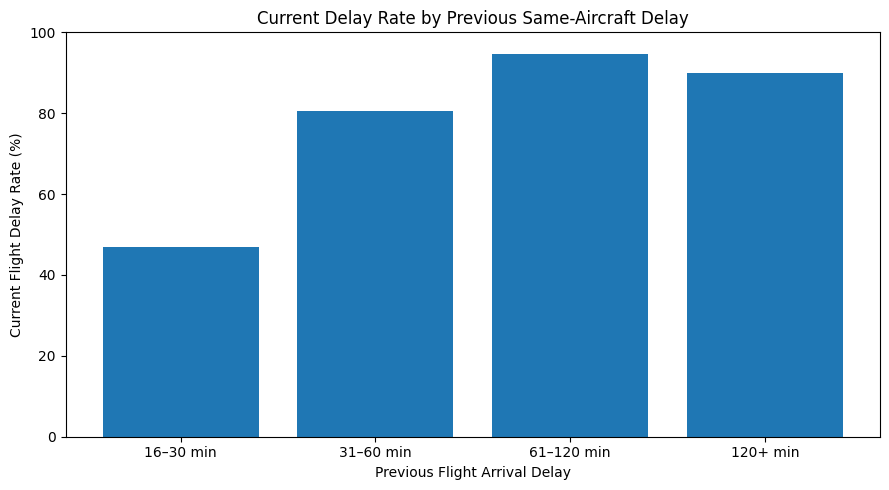

In [35]:
plt.figure(figsize=(9, 5))

plt.bar(
    previous_delay_analysis["PREV_DELAY_BUCKET"],
    previous_delay_analysis["delay_rate"]
)

plt.xlabel("Previous Flight Arrival Delay")
plt.ylabel("Current Flight Delay Rate (%)")
plt.title("Current Delay Rate by Previous Same-Aircraft Delay")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [36]:
operated[
    [
        "TAIL_NUMBER",
        "SCHEDULED_DATETIME",
        "ARRIVAL_TIME",
        "WHEELS_ON",
        "ARRIVAL_DELAY"
    ]
].head(10)

,TAIL_NUMBER,SCHEDULED_DATETIME,ARRIVAL_TIME,WHEELS_ON,ARRIVAL_DELAY
3458,7820L,2015-12-01 08:45:00,1105.0,1058.0,5.0
6233,7820L,2015-12-01 11:35:00,1147.0,1141.0,2.0
6942,7820L,2015-12-01 12:20:00,1330.0,1320.0,0.0
8539,7820L,2015-12-01 14:00:00,1834.0,1830.0,-11.0
13654,7820L,2015-12-01 19:20:00,2030.0,2021.0,-5.0
15007,7820L,2015-12-01 21:10:00,2238.0,2234.0,-12.0
17079,7820L,2015-12-02 06:35:00,945.0,937.0,-20.0
21112,7820L,2015-12-02 10:40:00,1642.0,1635.0,22.0
27051,7820L,2015-12-02 16:55:00,1946.0,1930.0,1.0
30420,7820L,2015-12-02 20:25:00,2256.0,2249.0,1.0


In [38]:
# Extract arrival hour and minute
arrival_hour = (
    operated["ARRIVAL_TIME"]
    .fillna(0)
    .astype(int) // 100
)

arrival_minute = (
    operated["ARRIVAL_TIME"]
    .fillna(0)
    .astype(int) % 100
)

# Create the date at midnight
arrival_date = pd.to_datetime(
    "2015-12-" + operated["DAY"].astype(str).str.zfill(2)
)

# Add hours and minutes
operated["ARRIVAL_DATETIME"] = (
    arrival_date
    + pd.to_timedelta(arrival_hour, unit="h")
    + pd.to_timedelta(arrival_minute, unit="m")
)

operated[
    [
        "TAIL_NUMBER",
        "DAY",
        "SCHEDULED_DATETIME",
        "ARRIVAL_TIME",
        "ARRIVAL_DATETIME"
    ]
].head(10)

,TAIL_NUMBER,DAY,SCHEDULED_DATETIME,ARRIVAL_TIME,ARRIVAL_DATETIME
3458,7820L,1,2015-12-01 08:45:00,1105.0,2015-12-01 11:05:00
6233,7820L,1,2015-12-01 11:35:00,1147.0,2015-12-01 11:47:00
6942,7820L,1,2015-12-01 12:20:00,1330.0,2015-12-01 13:30:00
8539,7820L,1,2015-12-01 14:00:00,1834.0,2015-12-01 18:34:00
13654,7820L,1,2015-12-01 19:20:00,2030.0,2015-12-01 20:30:00
15007,7820L,1,2015-12-01 21:10:00,2238.0,2015-12-01 22:38:00
17079,7820L,2,2015-12-02 06:35:00,945.0,2015-12-02 09:45:00
21112,7820L,2,2015-12-02 10:40:00,1642.0,2015-12-02 16:42:00
27051,7820L,2,2015-12-02 16:55:00,1946.0,2015-12-02 19:46:00
30420,7820L,2,2015-12-02 20:25:00,2256.0,2015-12-02 22:56:00


In [39]:
overnight_mask = (
    operated["ARRIVAL_DATETIME"] < operated["SCHEDULED_DATETIME"]
)

print("Potential overnight flights:", overnight_mask.sum())

Potential overnight flights: 23069


In [40]:
operated.loc[
    overnight_mask,
    "ARRIVAL_DATETIME"
] = operated.loc[
    overnight_mask,
    "ARRIVAL_DATETIME"
] + pd.Timedelta(days=1)

# Check again
print(
    "Still appearing before scheduled departure:",
    (
        operated["ARRIVAL_DATETIME"]
        < operated["SCHEDULED_DATETIME"]
    ).sum()
)

Still appearing before scheduled departure: 0


In [41]:
operated["PREV_ARRIVAL_DATETIME"] = (
    operated
    .groupby("TAIL_NUMBER")["ARRIVAL_DATETIME"]
    .shift(1)
)

operated["ACTUAL_TURNAROUND_GAP_HOURS"] = (
    operated["SCHEDULED_DATETIME"]
    - operated["PREV_ARRIVAL_DATETIME"]
).dt.total_seconds() / 3600

operated[
    [
        "TAIL_NUMBER",
        "PREV_ARRIVAL_DATETIME",
        "SCHEDULED_DATETIME",
        "ACTUAL_TURNAROUND_GAP_HOURS",
        "PREV_ARRIVAL_DELAY",
        "ARRIVAL_DELAY"
    ]
].head(20)

,TAIL_NUMBER,PREV_ARRIVAL_DATETIME,SCHEDULED_DATETIME,ACTUAL_TURNAROUND_GAP_HOURS,PREV_ARRIVAL_DELAY,ARRIVAL_DELAY
3458,7820L,NaT,2015-12-01 08:45:00,NaN,NaN,5.0
6233,7820L,2015-12-01 11:05:00,2015-12-01 11:35:00,0.500000,5.0,2.0
6942,7820L,2015-12-01 11:47:00,2015-12-01 12:20:00,0.550000,2.0,0.0
8539,7820L,2015-12-01 13:30:00,2015-12-01 14:00:00,0.500000,0.0,-11.0
13654,7820L,2015-12-01 18:34:00,2015-12-01 19:20:00,0.766667,-11.0,-5.0
15007,7820L,2015-12-01 20:30:00,2015-12-01 21:10:00,0.666667,-5.0,-12.0
17079,7820L,2015-12-01 22:38:00,2015-12-02 06:35:00,7.950000,-12.0,-20.0
21112,7820L,2015-12-02 09:45:00,2015-12-02 10:40:00,0.916667,-20.0,22.0
27051,7820L,2015-12-02 16:42:00,2015-12-02 16:55:00,0.216667,22.0,1.0
30420,7820L,2015-12-02 19:46:00,2015-12-02 20:25:00,0.650000,1.0,1.0


In [42]:
operated["ACTUAL_TURNAROUND_GAP_HOURS"].describe()

count    465303.000000
mean          3.774958
std          10.338421
min         -23.716667
25%           0.683333
50%           1.050000
75%           3.316667
max         692.966667
Name: ACTUAL_TURNAROUND_GAP_HOURS, dtype: float64

In [43]:
operated[
    operated["ACTUAL_TURNAROUND_GAP_HOURS"] < 0
][
    [
        "TAIL_NUMBER",
        "PREV_ARRIVAL_DATETIME",
        "SCHEDULED_DATETIME",
        "ACTUAL_TURNAROUND_GAP_HOURS",
        "PREV_ARRIVAL_DELAY",
        "ARRIVAL_DELAY"
    ]
].head(20)

,TAIL_NUMBER,PREV_ARRIVAL_DATETIME,SCHEDULED_DATETIME,ACTUAL_TURNAROUND_GAP_HOURS,PREV_ARRIVAL_DELAY,ARRIVAL_DELAY
206689,7820L,2015-12-14 13:34:00,2015-12-14 13:05:00,-0.483333,64.0,59.0
209891,7820L,2015-12-14 16:44:00,2015-12-14 16:25:00,-0.316667,59.0,39.0
267875,7820L,2015-12-18 09:59:00,2015-12-18 09:50:00,-0.150000,44.0,24.0
305207,7820L,2015-12-20 16:47:00,2015-12-20 16:30:00,-0.283333,2.0,45.0
306980,7820L,2015-12-20 18:30:00,2015-12-20 18:15:00,-0.250000,45.0,62.0
308760,7820L,2015-12-20 20:37:00,2015-12-20 20:10:00,-0.450000,62.0,54.0
336704,7820L,2015-12-22 16:27:00,2015-12-22 15:15:00,-1.200000,-13.0,310.0
446550,7820L,2015-12-29 18:36:00,2015-12-29 18:25:00,-0.183333,41.0,52.0
448198,7820L,2015-12-29 20:22:00,2015-12-29 20:15:00,-0.116667,52.0,60.0
459046,7820L,2015-12-30 15:30:00,2015-12-30 14:35:00,-0.916667,20.0,90.0


In [44]:
cascade_severity = (
    operated[
        operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4
    ]
    .groupby("PREV_WAS_DELAYED")
    .agg(
        flights=("ARRIVAL_DELAY", "count"),
        avg_current_delay=("ARRIVAL_DELAY", "mean"),
        median_current_delay=("ARRIVAL_DELAY", "median")
    )
    .reset_index()
)

cascade_severity

,PREV_WAS_DELAYED,flights,avg_current_delay,median_current_delay
0,0,224390,-1.527760,-6.0
1,1,47866,50.069047,32.0


In [45]:
rate_no_prev_delay = 10.996925
rate_prev_delay = 70.630510

relative_increase = (
    rate_prev_delay / rate_no_prev_delay
)

percentage_point_difference = (
    rate_prev_delay - rate_no_prev_delay
)

print("Relative increase:", relative_increase)
print("Percentage-point difference:", percentage_point_difference)

Relative increase: 6.422750905366728
Percentage-point difference: 59.633585000000004


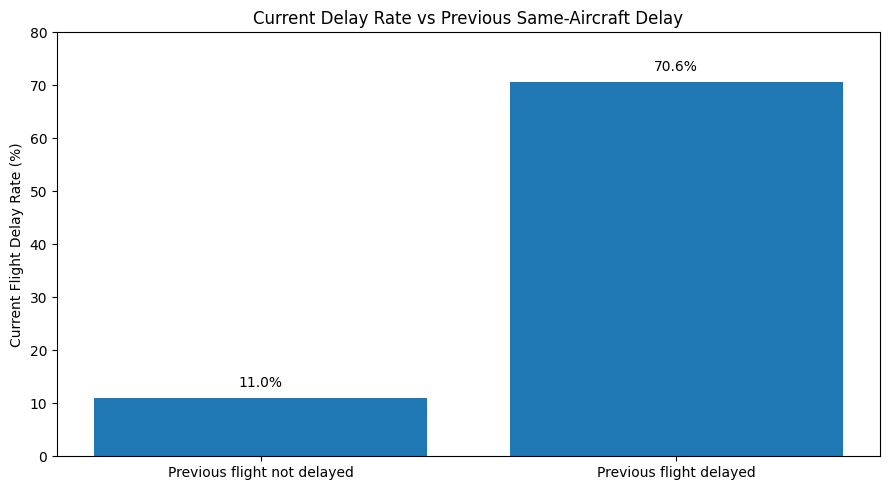

In [46]:
import matplotlib.pyplot as plt

cascade_plot = pd.DataFrame({
    "Previous Flight Status": [
        "Previous flight not delayed",
        "Previous flight delayed"
    ],
    "Current Delay Rate": [
        10.996925,
        70.630510
    ]
})

plt.figure(figsize=(9, 5))

bars = plt.bar(
    cascade_plot["Previous Flight Status"],
    cascade_plot["Current Delay Rate"]
)

plt.ylabel("Current Flight Delay Rate (%)")
plt.title("Current Delay Rate vs Previous Same-Aircraft Delay")

plt.ylim(0, 80)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [47]:
airport_summary = (
    operated
    .groupby("ORIGIN_AIRPORT")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum")
    )
    .reset_index()
)

airport_summary["delay_rate"] = (
    airport_summary["delayed_flights"]
    / airport_summary["total_flights"]
    * 100
)

airport_summary.sort_values(
    "total_flights",
    ascending=False
).head(20)

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate
18,ATL,30672,5348,17.436098
217,ORD,24612,5245,21.310743
81,DFW,19975,3641,18.227785
80,DEN,17531,4389,25.035651
166,LAX,16800,3853,22.934524
266,SFO,13422,3607,26.873789
228,PHX,13183,2548,19.327922
142,IAH,12245,2327,19.003675
164,LAS,11970,2583,21.578947
183,MCO,10682,2005,18.769893


In [48]:
airport_summary["total_flights"].describe()

count      307.000000
mean      1530.022801
std       3627.830291
min          6.000000
25%         85.000000
50%        238.000000
75%        848.500000
max      30672.000000
Name: total_flights, dtype: float64

In [49]:
thresholds = [100, 250, 500, 1000]

for threshold in thresholds:
    count = (airport_summary["total_flights"] >= threshold).sum()
    print(
        f"Airports with at least {threshold:,} flights: {count}"
    )

Airports with at least 100 flights: 221
Airports with at least 250 flights: 150
Airports with at least 500 flights: 104
Airports with at least 1,000 flights: 72


In [50]:
airport_filtered = airport_summary[
    airport_summary["total_flights"] >= 500
].copy()

print("Airports included:", len(airport_filtered))

airport_filtered.sort_values(
    "delay_rate",
    ascending=False
).head(15)

Airports included: 104


,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate
136,HPN,584,178,30.479452
173,LGB,752,214,28.457447
156,JFK,8166,2317,28.373745
211,OAK,3929,1102,28.047849
266,SFO,13422,3607,26.873789
80,DEN,17531,4389,25.035651
114,GEG,869,216,24.856157
249,RNO,1073,265,24.697111
76,DAL,5749,1395,24.265090
224,PBI,2398,581,24.228524


In [51]:
airport_filtered.sort_values(
    "delay_rate",
    ascending=True
).head(15)

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate
152,ITO,504,25,4.960317
174,LIH,991,60,6.054490
160,KOA,984,71,7.215447
133,HNL,3979,311,7.816034
212,OGG,1973,203,10.288900
15,ANC,1237,153,12.368634
232,PIT,2063,256,12.409113
251,ROC,673,90,13.372957
12,ALB,764,106,13.874346
47,BUF,1499,208,13.875917


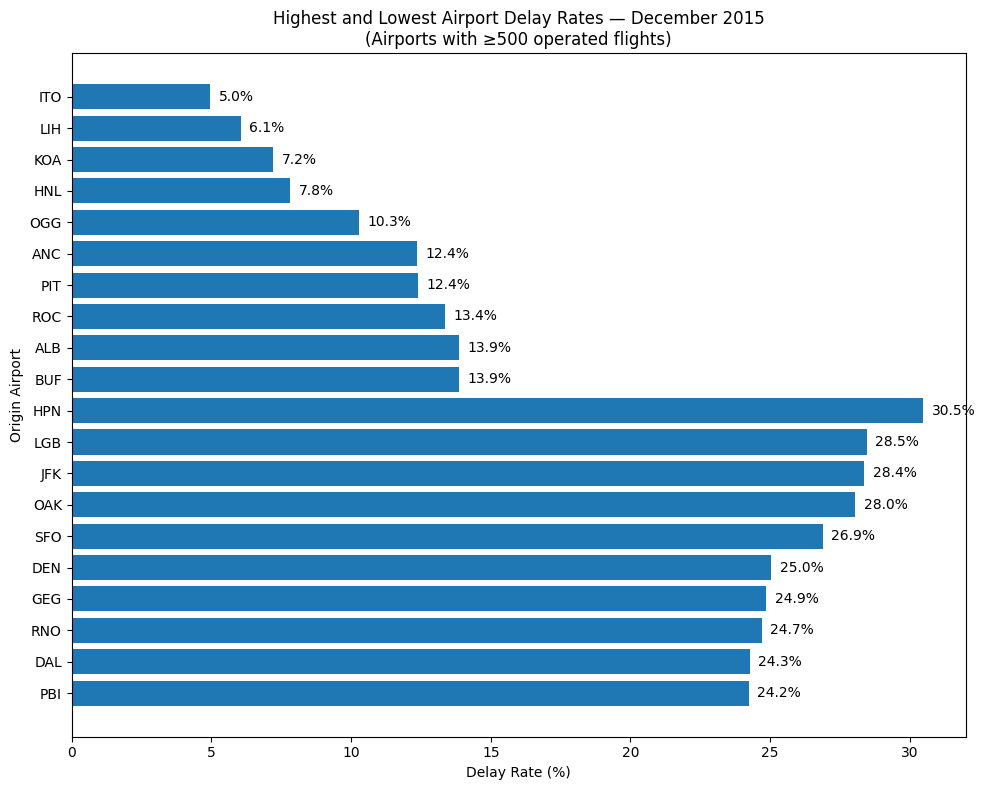

In [52]:
top_airports = (
    airport_filtered
    .sort_values("delay_rate", ascending=False)
    .head(10)
    .sort_values("delay_rate")
)

bottom_airports = (
    airport_filtered
    .sort_values("delay_rate", ascending=True)
    .head(10)
    .sort_values("delay_rate", ascending=False)
)

airport_plot = pd.concat([
    top_airports,
    bottom_airports
])

plt.figure(figsize=(10, 8))

bars = plt.barh(
    airport_plot["ORIGIN_AIRPORT"],
    airport_plot["delay_rate"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Origin Airport")
plt.title(
    "Highest and Lowest Airport Delay Rates — December 2015\n"
    "(Airports with ≥500 operated flights)"
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [53]:
airports = pd.read_csv("../data/airports.csv")

print("Shape:", airports.shape)
print("\nColumns:")
print(airports.columns.tolist())

airports.head()

Shape: (322, 7)

Columns:
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [54]:
airport_lookup = airports[
    [
        "IATA_CODE",
        "AIRPORT",
        "CITY",
        "STATE"
    ]
].copy()

airport_summary_named = airport_summary.merge(
    airport_lookup,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

airport_summary_named = airport_summary_named.drop(
    columns=["IATA_CODE"]
)

airport_summary_named.head()

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate,AIRPORT,CITY,STATE
0,ABE,149,21,14.093960,Lehigh Valley International Airport,Allentown,PA
1,ABI,196,24,12.244898,Abilene Regional Airport,Abilene,TX
2,ABQ,1589,384,24.166142,Albuquerque International Sunport,Albuquerque,NM
3,ABR,61,18,29.508197,Aberdeen Regional Airport,Aberdeen,SD
4,ABY,75,17,22.666667,Southwest Georgia Regional Airport,Albany,GA


In [55]:
airport_filtered_named = airport_summary_named[
    airport_summary_named["total_flights"] >= 500
].copy()

airport_filtered_named = airport_filtered_named.sort_values(
    "delay_rate",
    ascending=False
)

airport_filtered_named.head(10)

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate,AIRPORT,CITY,STATE
136,HPN,584,178,30.479452,Westchester County Airport,White Plains,NY
173,LGB,752,214,28.457447,Long Beach Airport (Daugherty Field),Long Beach,CA
156,JFK,8166,2317,28.373745,John F. Kennedy International Airport (New Yor...,New York,NY
211,OAK,3929,1102,28.047849,Oakland International Airport,Oakland,CA
266,SFO,13422,3607,26.873789,San Francisco International Airport,San Francisco,CA
80,DEN,17531,4389,25.035651,Denver International Airport,Denver,CO
114,GEG,869,216,24.856157,Spokane International Airport,Spokane,WA
249,RNO,1073,265,24.697111,Reno/Tahoe International Airport,Reno,NV
76,DAL,5749,1395,24.265090,Dallas Love Field,Dallas,TX
224,PBI,2398,581,24.228524,Palm Beach International Airport,West Palm Beach,FL


In [56]:
day_summary = (
    operated
    .groupby("DAY_OF_WEEK")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
    .reset_index()
)

day_summary["delay_rate"] = (
    day_summary["delayed_flights"]
    / day_summary["total_flights"]
    * 100
)

day_summary

,DAY_OF_WEEK,total_flights,delayed_flights,avg_arrival_delay,delay_rate
0,1,61731,13511,9.494517,21.886896
1,2,77886,16412,7.381211,21.071823
2,3,79567,19472,9.366873,24.472457
3,4,74771,13332,4.333538,17.830442
4,5,61337,9061,0.852128,14.772486
5,6,53535,8994,2.280601,16.800224
6,7,60890,12531,7.509690,20.579734


In [57]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_summary["DAY_NAME"] = day_summary["DAY_OF_WEEK"].map(day_names)

day_summary

,DAY_OF_WEEK,total_flights,delayed_flights,avg_arrival_delay,delay_rate,DAY_NAME
0,1,61731,13511,9.494517,21.886896,Monday
1,2,77886,16412,7.381211,21.071823,Tuesday
2,3,79567,19472,9.366873,24.472457,Wednesday
3,4,74771,13332,4.333538,17.830442,Thursday
4,5,61337,9061,0.852128,14.772486,Friday
5,6,53535,8994,2.280601,16.800224,Saturday
6,7,60890,12531,7.509690,20.579734,Sunday


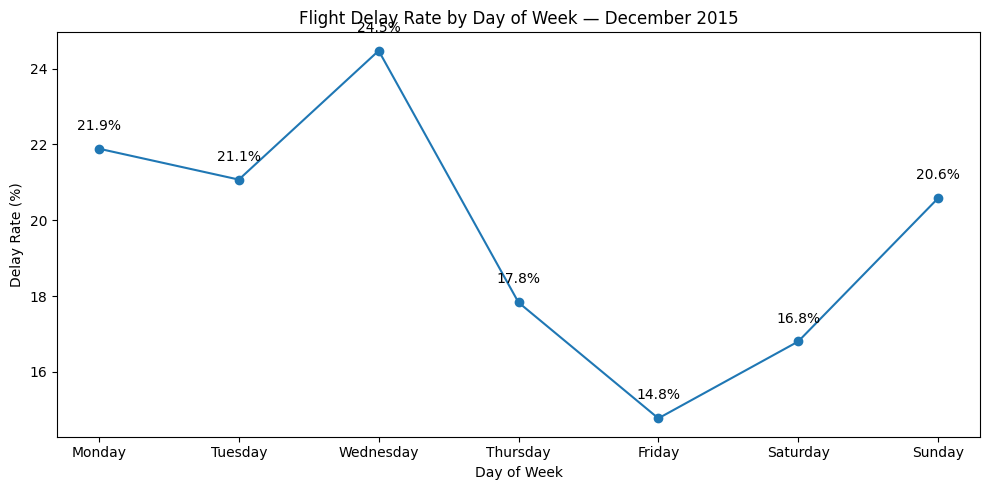

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    day_summary["DAY_NAME"],
    day_summary["delay_rate"],
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.title("Flight Delay Rate by Day of Week — December 2015")

for x, y in zip(
    day_summary["DAY_NAME"],
    day_summary["delay_rate"]
):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [59]:
hour_cascade = (
    operated[
        operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4
    ]
    .groupby(["DEP_HOUR", "PREV_WAS_DELAYED"])
    .agg(
        flights=("IS_DELAYED", "count"),
        delayed_flights=("IS_DELAYED", "sum")
    )
    .reset_index()
)

hour_cascade["delay_rate"] = (
    hour_cascade["delayed_flights"]
    / hour_cascade["flights"]
    * 100
)

hour_cascade.head(20)

,DEP_HOUR,PREV_WAS_DELAYED,flights,delayed_flights,delay_rate
0,0,0,384,59,15.364583
1,0,1,162,91,56.172840
2,1,0,116,13,11.206897
3,1,1,57,34,59.649123
4,2,0,11,1,9.090909
5,2,1,1,0,0.000000
6,5,0,7,5,71.428571
7,6,0,387,53,13.695090
8,6,1,33,12,36.363636
9,7,0,3919,457,11.661138


In [60]:
hour_prev_delay = (
    operated[
        operated["PREV_FLIGHT_TIME_GAP_HOURS"] <= 4
    ]
    .groupby("DEP_HOUR")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        flights_with_prev_delay=("PREV_WAS_DELAYED", "sum")
    )
    .reset_index()
)

hour_prev_delay["prev_delay_share"] = (
    hour_prev_delay["flights_with_prev_delay"]
    / hour_prev_delay["total_flights"]
    * 100
)

hour_prev_delay

,DEP_HOUR,total_flights,flights_with_prev_delay,prev_delay_share
0,0,546,162,29.670330
1,1,173,57,32.947977
2,2,12,1,8.333333
3,5,7,0,0.000000
4,6,420,33,7.857143
5,7,4222,303,7.176694
6,8,12875,1049,8.147573
7,9,19375,2057,10.616774
8,10,21507,2777,12.912075
9,11,21447,2966,13.829440


In [61]:
daytime_prev_delay = hour_prev_delay[
    hour_prev_delay["DEP_HOUR"].between(5, 21)
].copy()

correlation = daytime_prev_delay["DEP_HOUR"].corr(
    daytime_prev_delay["prev_delay_share"]
)

print("Correlation:", correlation)

Correlation: 0.9765978875544007


In [62]:
print(flights_dec.shape)
print(flights_dec.columns.tolist())

(479230, 35)
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'IS_DELAYED', 'IATA_CODE', 'AIRLINE_NAME', 'DEP_HOUR']


In [63]:
flights_dec.to_csv(
    "../data/flights_dec2015_clean.csv",
    index=False
)

print("Final EDA dataset saved successfully.")
print("Shape:", flights_dec.shape)

Final EDA dataset saved successfully.
Shape: (479230, 35)


In [1]:
import sqlite3

print("SQLite version:", sqlite3.sqlite_version)

SQLite version: 3.45.3


In [2]:
import sqlite3

db_path = "../data/flight_delay.db"

conn = sqlite3.connect(db_path)

print("Database connected successfully!")
print("Database:", db_path)

Database connected successfully!
Database: ../data/flight_delay.db


In [3]:
import pandas as pd

csv_path = "../data/flights_dec2015_clean.csv"

flights_sql = pd.read_csv(csv_path)

flights_sql.to_sql(
    "flights",
    conn,
    if_exists="replace",
    index=False
)

print("CSV loaded into SQLite successfully!")
print("Rows:", len(flights_sql))

CSV loaded into SQLite successfully!
Rows: 479230


In [4]:
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM flights")
row_count = cursor.fetchone()[0]

print("Rows in SQLite:", row_count)

Rows in SQLite: 479230


In [5]:
cursor.execute("PRAGMA table_info(flights)")

columns = cursor.fetchall()

for column in columns:
    print(column)

(0, 'YEAR', 'INTEGER', 0, None, 0)
(1, 'MONTH', 'INTEGER', 0, None, 0)
(2, 'DAY', 'INTEGER', 0, None, 0)
(3, 'DAY_OF_WEEK', 'INTEGER', 0, None, 0)
(4, 'AIRLINE', 'TEXT', 0, None, 0)
(5, 'FLIGHT_NUMBER', 'INTEGER', 0, None, 0)
(6, 'TAIL_NUMBER', 'TEXT', 0, None, 0)
(7, 'ORIGIN_AIRPORT', 'TEXT', 0, None, 0)
(8, 'DESTINATION_AIRPORT', 'TEXT', 0, None, 0)
(9, 'SCHEDULED_DEPARTURE', 'INTEGER', 0, None, 0)
(10, 'DEPARTURE_TIME', 'REAL', 0, None, 0)
(11, 'DEPARTURE_DELAY', 'REAL', 0, None, 0)
(12, 'TAXI_OUT', 'REAL', 0, None, 0)
(13, 'WHEELS_OFF', 'REAL', 0, None, 0)
(14, 'SCHEDULED_TIME', 'REAL', 0, None, 0)
(15, 'ELAPSED_TIME', 'REAL', 0, None, 0)
(16, 'AIR_TIME', 'REAL', 0, None, 0)
(17, 'DISTANCE', 'INTEGER', 0, None, 0)
(18, 'WHEELS_ON', 'REAL', 0, None, 0)
(19, 'TAXI_IN', 'REAL', 0, None, 0)
(20, 'SCHEDULED_ARRIVAL', 'INTEGER', 0, None, 0)
(21, 'ARRIVAL_TIME', 'REAL', 0, None, 0)
(22, 'ARRIVAL_DELAY', 'REAL', 0, None, 0)
(23, 'DIVERTED', 'INTEGER', 0, None, 0)
(24, 'CANCELLED', 'INTEGER

In [6]:
query = """
SELECT
    COUNT(*) AS operated_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0;
"""

result = pd.read_sql_query(query, conn)

result

,operated_flights,delayed_flights,delay_rate_percent
0,469717,93313,19.87


In [7]:
query = """
SELECT
    AIRLINE_NAME,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
GROUP BY AIRLINE_NAME
ORDER BY delay_rate_percent DESC;
"""

airline_sql = pd.read_sql_query(query, conn)

airline_sql

,AIRLINE_NAME,total_flights,delayed_flights,delay_rate_percent
0,Spirit Air Lines,10473,3042,29.05
1,JetBlue Airways,23197,6651,28.67
2,Virgin America,5470,1487,27.18
3,Skywest Airlines Inc.,45984,10836,23.56
4,Frontier Airlines Inc.,8018,1878,23.42
5,Southwest Airlines Co.,105569,22840,21.64
6,United Air Lines Inc.,42554,8481,19.93
7,Atlantic Southeast Airlines,42430,8013,18.89
8,American Airlines Inc.,75078,13840,18.43
9,American Eagle Airlines Inc.,20091,3113,15.49


In [8]:
query = """
SELECT
    AIRLINE_NAME,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,

    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent,

    ROUND(
        AVG(ARRIVAL_DELAY),
        2
    ) AS avg_arrival_delay,

    ROUND(
        AVG(
            CASE
                WHEN IS_DELAYED = 1 THEN ARRIVAL_DELAY
            END
        ),
        2
    ) AS avg_delay_when_delayed

FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0

GROUP BY AIRLINE_NAME
ORDER BY delay_rate_percent DESC;
"""

airline_severity_sql = pd.read_sql_query(query, conn)

airline_severity_sql

,AIRLINE_NAME,total_flights,delayed_flights,delay_rate_percent,avg_arrival_delay,avg_delay_when_delayed
0,Spirit Air Lines,10473,3042,29.05,12.73,58.41
1,JetBlue Airways,23197,6651,28.67,13.84,66.33
2,Virgin America,5470,1487,27.18,13.50,70.20
3,Skywest Airlines Inc.,45984,10836,23.56,10.95,68.07
4,Frontier Airlines Inc.,8018,1878,23.42,9.35,76.67
5,Southwest Airlines Co.,105569,22840,21.64,6.72,53.81
6,United Air Lines Inc.,42554,8481,19.93,7.01,80.99
7,Atlantic Southeast Airlines,42430,8013,18.89,6.69,69.72
8,American Airlines Inc.,75078,13840,18.43,4.15,60.53
9,American Eagle Airlines Inc.,20091,3113,15.49,0.66,65.92


In [9]:
query = """
SELECT
    SUM(AIR_SYSTEM_DELAY) AS air_system_delay_minutes,
    SUM(SECURITY_DELAY) AS security_delay_minutes,
    SUM(AIRLINE_DELAY) AS airline_delay_minutes,
    SUM(LATE_AIRCRAFT_DELAY) AS late_aircraft_delay_minutes,
    SUM(WEATHER_DELAY) AS weather_delay_minutes
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1;
"""

cause_sql = pd.read_sql_query(query, conn)

cause_sql

,air_system_delay_minutes,security_delay_minutes,airline_delay_minutes,late_aircraft_delay_minutes,weather_delay_minutes
0,1264646.0,9761.0,1881224.0,2525932.0,326068.0


In [10]:
query = """
SELECT 'Air System' AS delay_cause,
       SUM(AIR_SYSTEM_DELAY) AS total_delay_minutes
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1

UNION ALL

SELECT 'Security',
       SUM(SECURITY_DELAY)
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1

UNION ALL

SELECT 'Airline',
       SUM(AIRLINE_DELAY)
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1

UNION ALL

SELECT 'Late Aircraft',
       SUM(LATE_AIRCRAFT_DELAY)
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1

UNION ALL

SELECT 'Weather',
       SUM(WEATHER_DELAY)
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
  AND IS_DELAYED = 1

ORDER BY total_delay_minutes DESC;
"""

cause_long_sql = pd.read_sql_query(query, conn)

cause_long_sql

,delay_cause,total_delay_minutes
0,Late Aircraft,2525932.0
1,Airline,1881224.0
2,Air System,1264646.0
3,Weather,326068.0
4,Security,9761.0


In [11]:
query = """
SELECT
    ORIGIN_AIRPORT,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
GROUP BY ORIGIN_AIRPORT
ORDER BY total_flights DESC;
"""

airport_sql = pd.read_sql_query(query, conn)

airport_sql.head(20)

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate_percent
0,ATL,30672,5348,17.44
1,ORD,24612,5245,21.31
2,DFW,19975,3641,18.23
3,DEN,17531,4389,25.04
4,LAX,16800,3853,22.93
5,SFO,13422,3607,26.87
6,PHX,13183,2548,19.33
7,IAH,12245,2327,19.00
8,LAS,11970,2583,21.58
9,MCO,10682,2005,18.77


In [12]:
query = """
SELECT
    ORIGIN_AIRPORT,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
GROUP BY ORIGIN_AIRPORT
HAVING COUNT(*) >= 500
ORDER BY delay_rate_percent DESC;
"""

airport_filtered_sql = pd.read_sql_query(query, conn)

airport_filtered_sql.head(15)

,ORIGIN_AIRPORT,total_flights,delayed_flights,delay_rate_percent
0,HPN,584,178,30.48
1,LGB,752,214,28.46
2,JFK,8166,2317,28.37
3,OAK,3929,1102,28.05
4,SFO,13422,3607,26.87
5,DEN,17531,4389,25.04
6,GEG,869,216,24.86
7,RNO,1073,265,24.70
8,DAL,5749,1395,24.27
9,PBI,2398,581,24.23


In [13]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

pd.read_sql_query(query, conn)

,name
0,flights


In [14]:
airports = pd.read_csv("../data/airports.csv")

airports_sql = airports[
    ["IATA_CODE", "AIRPORT", "CITY", "STATE"]
].copy()

airports_sql.to_sql(
    "airports",
    conn,
    if_exists="replace",
    index=False
)

print("Airport lookup loaded successfully!")
print("Rows:", len(airports_sql))

Airport lookup loaded successfully!
Rows: 322


In [15]:
query = """
SELECT
    f.ORIGIN_AIRPORT,
    a.AIRPORT AS airport_name,
    a.CITY,
    a.STATE,
    COUNT(*) AS total_flights,
    SUM(f.IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(f.IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent

FROM flights AS f

LEFT JOIN airports AS a
    ON f.ORIGIN_AIRPORT = a.IATA_CODE

WHERE f.CANCELLED = 0
  AND f.DIVERTED = 0

GROUP BY
    f.ORIGIN_AIRPORT,
    a.AIRPORT,
    a.CITY,
    a.STATE

HAVING COUNT(*) >= 500

ORDER BY delay_rate_percent DESC;
"""

airport_named_sql = pd.read_sql_query(query, conn)

airport_named_sql.head(15)

,ORIGIN_AIRPORT,airport_name,CITY,STATE,total_flights,delayed_flights,delay_rate_percent
0,HPN,Westchester County Airport,White Plains,NY,584,178,30.48
1,LGB,Long Beach Airport (Daugherty Field),Long Beach,CA,752,214,28.46
2,JFK,John F. Kennedy International Airport (New Yor...,New York,NY,8166,2317,28.37
3,OAK,Oakland International Airport,Oakland,CA,3929,1102,28.05
4,SFO,San Francisco International Airport,San Francisco,CA,13422,3607,26.87
5,DEN,Denver International Airport,Denver,CO,17531,4389,25.04
6,GEG,Spokane International Airport,Spokane,WA,869,216,24.86
7,RNO,Reno/Tahoe International Airport,Reno,NV,1073,265,24.70
8,DAL,Dallas Love Field,Dallas,TX,5749,1395,24.27
9,PBI,Palm Beach International Airport,West Palm Beach,FL,2398,581,24.23


In [16]:
query = """
SELECT *
FROM (
    SELECT
        f.ORIGIN_AIRPORT,
        a.AIRPORT AS airport_name,
        a.CITY,
        a.STATE,
        COUNT(*) AS total_flights,
        SUM(f.IS_DELAYED) AS delayed_flights,
        ROUND(
            100.0 * SUM(f.IS_DELAYED) / COUNT(*),
            2
        ) AS delay_rate_percent

    FROM flights AS f

    LEFT JOIN airports AS a
        ON f.ORIGIN_AIRPORT = a.IATA_CODE

    WHERE f.CANCELLED = 0
      AND f.DIVERTED = 0

    GROUP BY
        f.ORIGIN_AIRPORT,
        a.AIRPORT,
        a.CITY,
        a.STATE

    HAVING COUNT(*) >= 500
)
ORDER BY delay_rate_percent ASC
LIMIT 15;
"""

airport_low_sql = pd.read_sql_query(query, conn)

airport_low_sql

,ORIGIN_AIRPORT,airport_name,CITY,STATE,total_flights,delayed_flights,delay_rate_percent
0,ITO,Hilo International Airport,Hilo,HI,504,25,4.96
1,LIH,Lihue Airport,Lihue,HI,991,60,6.05
2,KOA,Kona International Airport at Keahole,Kailua/Kona,HI,984,71,7.22
3,HNL,Honolulu International Airport,Honolulu,HI,3979,311,7.82
4,OGG,Kahului Airport,Kahului,HI,1973,203,10.29
5,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,1237,153,12.37
6,PIT,Pittsburgh International Airport,Pittsburgh,PA,2063,256,12.41
7,ROC,Greater Rochester International Airport,Rochester,NY,673,90,13.37
8,ALB,Albany International Airport,Albany,NY,764,106,13.87
9,BUF,Buffalo Niagara International Airport,Buffalo,NY,1499,208,13.88


In [17]:
query = """
SELECT
    DAY_OF_WEEK,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent,
    ROUND(
        AVG(ARRIVAL_DELAY),
        2
    ) AS avg_arrival_delay
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
GROUP BY DAY_OF_WEEK
ORDER BY DAY_OF_WEEK;
"""

day_sql = pd.read_sql_query(query, conn)

day_sql

,DAY_OF_WEEK,total_flights,delayed_flights,delay_rate_percent,avg_arrival_delay
0,1,61731,13511,21.89,9.49
1,2,77886,16412,21.07,7.38
2,3,79567,19472,24.47,9.37
3,4,74771,13332,17.83,4.33
4,5,61337,9061,14.77,0.85
5,6,53535,8994,16.80,2.28
6,7,60890,12531,20.58,7.51


In [18]:
query = """
SELECT
    DEP_HOUR,
    COUNT(*) AS total_flights,
    SUM(IS_DELAYED) AS delayed_flights,
    ROUND(
        100.0 * SUM(IS_DELAYED) / COUNT(*),
        2
    ) AS delay_rate_percent,
    ROUND(
        AVG(ARRIVAL_DELAY),
        2
    ) AS avg_arrival_delay
FROM flights
WHERE CANCELLED = 0
  AND DIVERTED = 0
GROUP BY DEP_HOUR
ORDER BY DEP_HOUR;
"""

hour_sql = pd.read_sql_query(query, conn)

hour_sql

,DEP_HOUR,total_flights,delayed_flights,delay_rate_percent,avg_arrival_delay
0,0,1533,299,19.50,5.39
1,1,547,112,20.48,2.08
2,2,164,29,17.68,-1.56
3,3,86,21,24.42,8.93
4,4,66,22,33.33,5.86
5,5,11135,1092,9.81,-0.84
6,6,32632,3620,11.09,-0.87
7,7,31186,4123,13.22,0.04
8,8,30089,4437,14.75,1.49
9,9,28643,4736,16.53,3.82


In [19]:
query = """
WITH flight_sequence AS (
    SELECT
        TAIL_NUMBER,
        DAY,
        SCHEDULED_DEPARTURE,
        ARRIVAL_DELAY,
        IS_DELAYED,

        LAG(ARRIVAL_DELAY) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_ARRIVAL_DELAY

    FROM flights

    WHERE CANCELLED = 0
      AND DIVERTED = 0
)

SELECT
    CASE
        WHEN PREV_ARRIVAL_DELAY > 15 THEN 'Previous flight delayed'
        ELSE 'Previous flight not delayed'
    END AS previous_flight_status,

    COUNT(*) AS total_flights,

    SUM(
        CASE
            WHEN ARRIVAL_DELAY > 15 THEN 1
            ELSE 0
        END
    ) AS delayed_flights,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN ARRIVAL_DELAY > 15 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS delay_rate_percent

FROM flight_sequence

WHERE PREV_ARRIVAL_DELAY IS NOT NULL

GROUP BY previous_flight_status
ORDER BY previous_flight_status;
"""

cascade_sql = pd.read_sql_query(query, conn)

cascade_sql

,previous_flight_status,total_flights,delayed_flights,delay_rate_percent
0,Previous flight delayed,92499,48259,52.17
1,Previous flight not delayed,372804,44469,11.93


In [20]:
query = """
WITH flight_sequence AS (
    SELECT
        TAIL_NUMBER,
        DAY,
        SCHEDULED_DEPARTURE,
        ARRIVAL_DELAY,
        IS_DELAYED,

        LAG(ARRIVAL_DELAY) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_ARRIVAL_DELAY,

        LAG(DAY) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_DAY,

        LAG(SCHEDULED_DEPARTURE) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_SCHEDULED_DEPARTURE

    FROM flights

    WHERE CANCELLED = 0
      AND DIVERTED = 0
),

with_gap AS (
    SELECT
        *,
        (
            (DAY - PREV_DAY) * 24
            +
            (
                (SCHEDULED_DEPARTURE / 100) * 60
                + (SCHEDULED_DEPARTURE % 100)
                -
                (
                    (PREV_SCHEDULED_DEPARTURE / 100) * 60
                    + (PREV_SCHEDULED_DEPARTURE % 100)
                )
            ) / 60.0
        ) AS scheduled_gap_hours

    FROM flight_sequence
    WHERE PREV_DAY IS NOT NULL
)

SELECT
    CASE
        WHEN PREV_ARRIVAL_DELAY > 15
            THEN 'Previous flight delayed'
        ELSE 'Previous flight not delayed'
    END AS previous_flight_status,

    COUNT(*) AS total_flights,

    SUM(
        CASE
            WHEN ARRIVAL_DELAY > 15 THEN 1
            ELSE 0
        END
    ) AS delayed_flights,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN ARRIVAL_DELAY > 15 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS delay_rate_percent

FROM with_gap

WHERE scheduled_gap_hours <= 4

GROUP BY previous_flight_status
ORDER BY previous_flight_status;
"""

cascade_4h_sql = pd.read_sql_query(query, conn)

cascade_4h_sql

,previous_flight_status,total_flights,delayed_flights,delay_rate_percent
0,Previous flight delayed,47866,33808,70.63
1,Previous flight not delayed,224390,24676,11.00


In [23]:
query = """
WITH flight_sequence AS (
    SELECT
        TAIL_NUMBER,
        DAY,
        SCHEDULED_DEPARTURE,
        ARRIVAL_DELAY,
        IS_DELAYED,

        LAG(ARRIVAL_DELAY) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_ARRIVAL_DELAY,

        LAG(DAY) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_DAY,

        LAG(SCHEDULED_DEPARTURE) OVER (
            PARTITION BY TAIL_NUMBER
            ORDER BY DAY, SCHEDULED_DEPARTURE
        ) AS PREV_SCHEDULED_DEPARTURE

    FROM flights

    WHERE CANCELLED = 0
      AND DIVERTED = 0
),

with_gap AS (
    SELECT
        *,
        (
            (DAY - PREV_DAY) * 24
            +
            (
                (SCHEDULED_DEPARTURE / 100) * 60
                + (SCHEDULED_DEPARTURE % 100)
                -
                (
                    (PREV_SCHEDULED_DEPARTURE / 100) * 60
                    + (PREV_SCHEDULED_DEPARTURE % 100)
                )
            ) / 60.0
        ) AS scheduled_gap_hours

    FROM flight_sequence

    WHERE PREV_DAY IS NOT NULL
),

cascade_count AS (
    SELECT
        SUM(
            CASE
                WHEN IS_DELAYED = 1
                 AND PREV_ARRIVAL_DELAY > 15
                 AND scheduled_gap_hours <= 4
                THEN 1
                ELSE 0
            END
        ) AS potential_cascade_flights

    FROM with_gap
)

SELECT
    (
        SELECT COUNT(*)
        FROM flights
        WHERE IS_DELAYED = 1
    ) AS delayed_flights,

    potential_cascade_flights,

    ROUND(
        100.0 * potential_cascade_flights /
        (
            SELECT COUNT(*)
            FROM flights
            WHERE IS_DELAYED = 1
        ),
        2
    ) AS potential_cascade_rate_percent

FROM cascade_count;
"""

cascade_metric_sql = pd.read_sql_query(query, conn)

cascade_metric_sql

,delayed_flights,potential_cascade_flights,potential_cascade_rate_percent
0,93313,33808,36.23
